In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data =  pd.read_csv("Scraping_folder/data.csv")
data.head()

/tmp/ipykernel_28963/2324862443.py:5: DtypeWarning: Columns (0: pl_occdepstr, 1: pl_occdep_reflink) have mixed types. Specify dtype option on import or set low_memory=False.
  data =  pd.read_csv("Scraping_folder/data.csv")


,systemid,sy_name,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,...,pl_tsm_solnid,pl_tsmstr,pl_tsmlim,pl_esm,pl_esmerr1,pl_esmerr2,pl_esm_reflink,pl_esm_solnid,pl_esmstr,pl_esmlim
0,1.539830,HD 2039,3.11204,HD 2039 b,b,2.539830,HD 2039,HD 2039,HIP 1931,TIC 281461362,...,NaN,NaN,NaN,0.1,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,0.0,0.0
1,1.103446,HAT-P-8,3.11027,HAT-P-8 b,b,2.103446,HAT-P-8,NaN,NaN,TIC 188876052,...,NaN,109.0,0.0,120.0,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,120.0,0.0
2,1.643080,K2-43,3.88640,K2-43 b,b,2.643080,K2-43,NaN,NaN,TIC 443616612,...,NaN,60.0,0.0,14.5,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,15.0,0.0
3,1.567687,Kepler-1753,3.15620,Kepler-1753 b,b,2.567687,Kepler-1753,NaN,NaN,TIC 158664331,...,NaN,4.0,0.0,0.1,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,0.0,0.0
4,1.544946,Kepler-1176,3.24120,Kepler-1176 b,b,2.544946,Kepler-1176,NaN,NaN,TIC 273582656,...,NaN,3.0,0.0,0.1,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,0.0,0.0


In [2]:
feature_df = pd.DataFrame({
    "Feature": data.columns,
    "DataType": data.dtypes.values,
    "MissingValues": data.isnull().sum().values
})
feature_df

,Feature,DataType,MissingValues
0,systemid,float64,0
1,sy_name,str,0
2,objectid,float64,0
3,pl_name,str,0
4,pl_letter,str,0
...,...,...,...
698,pl_esmerr2,float64,6366
699,pl_esm_reflink,str,601
700,pl_esm_solnid,float64,6366
701,pl_esmstr,float64,601


## REDUCE FEATURE

In [3]:
core_cols = [
    'pl_name', 'discoverymethod', 'disc_year', 
    'sy_dist', 'pl_orbper', 'pl_rade', 'pl_bmasse', 'pl_eqt'
]

available_cols = [col for col in core_cols if col in data.columns]
data = data[available_cols].copy()
data.head()

,pl_name,discoverymethod,disc_year,sy_dist,pl_orbper,pl_rade,pl_bmasse,pl_eqt
0,HD 2039 b,Radial Velocity,2002,85.6922,1120.000000,12.700000,1999.1507,210.84
1,HAT-P-8 b,Transit,2008,211.5530,3.076340,15.692600,406.8224,1713.00
2,K2-43 b,Transit,2016,182.5360,3.471149,4.510000,18.5000,939.30
3,Kepler-1753 b,Transit,2021,707.6880,16.004601,2.226781,5.5900,583.00
4,Kepler-1176 b,Transit,2016,864.6990,24.173858,2.450000,6.5700,595.00


In [4]:
data.describe()

,disc_year,sy_dist,pl_orbper,pl_rade,pl_bmasse,pl_eqt
count,6366.000000,6338.00000,6.016000e+03,6316.000000,6335.000000,5832.000000
mean,2017.288407,709.53872,7.116076e+04,5.875301,405.241672,835.130672
std,5.141004,1230.75415,5.185317e+06,5.428426,1138.932269,496.505889
min,1992.000000,1.30119,9.070629e-02,0.309800,0.020000,1.480000
25%,2014.000000,101.37250,4.304564e+00,1.850000,4.310000,485.965000
50%,2016.000000,359.43900,1.074551e+01,2.870000,9.400000,756.185000
75%,2021.000000,823.35975,3.857813e+01,11.984300,194.327664,1093.000000
max,2026.000000,8500.00000,4.020000e+08,87.205870,9534.852210,7777.780000


## Data Preprocesing

In [5]:
feature_df = pd.DataFrame({
    "Feature": data.columns,
    "DataType": data.dtypes.values,
    "MissingValues": data.isnull().sum().values
})
feature_df

,Feature,DataType,MissingValues
0,pl_name,str,0
1,discoverymethod,str,0
2,disc_year,int64,0
3,sy_dist,float64,28
4,pl_orbper,float64,350
5,pl_rade,float64,50
6,pl_bmasse,float64,31
7,pl_eqt,float64,534


In [6]:
data.dropna(subset=['sy_dist', 'pl_rade', 'pl_bmasse', 'pl_eqt'], inplace=True)
feature_df = pd.DataFrame({
    "Feature": data.columns,
    "DataType": data.dtypes.values,
    "MissingValues": data.isnull().sum().values
})
feature_df

,Feature,DataType,MissingValues
0,pl_name,str,0
1,discoverymethod,str,0
2,disc_year,int64,0
3,sy_dist,float64,0
4,pl_orbper,float64,64
5,pl_rade,float64,0
6,pl_bmasse,float64,0
7,pl_eqt,float64,0


In [7]:
data['sy_dist_kly'] = (data['sy_dist'] * 3.26) / 1000

## Discovery Timeline & Methods

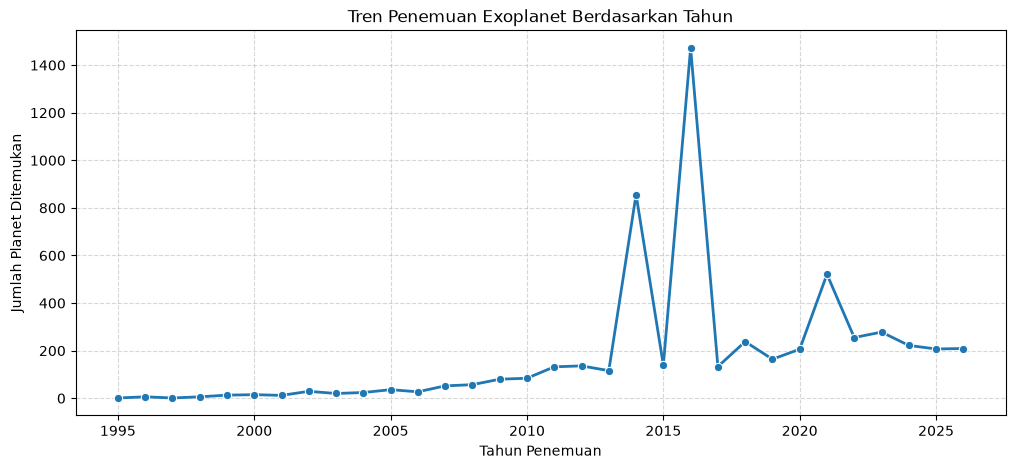

In [8]:
plt.figure(figsize=(12, 5))
tren_tahun = data['disc_year'].value_counts()

sns.lineplot(x=tren_tahun.index, y=tren_tahun.values, marker='o', linewidth=2)
plt.title('Tren Penemuan Exoplanet Berdasarkan Tahun')
plt.xlabel('Tahun Penemuan')
plt.ylabel('Jumlah Planet Ditemukan')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

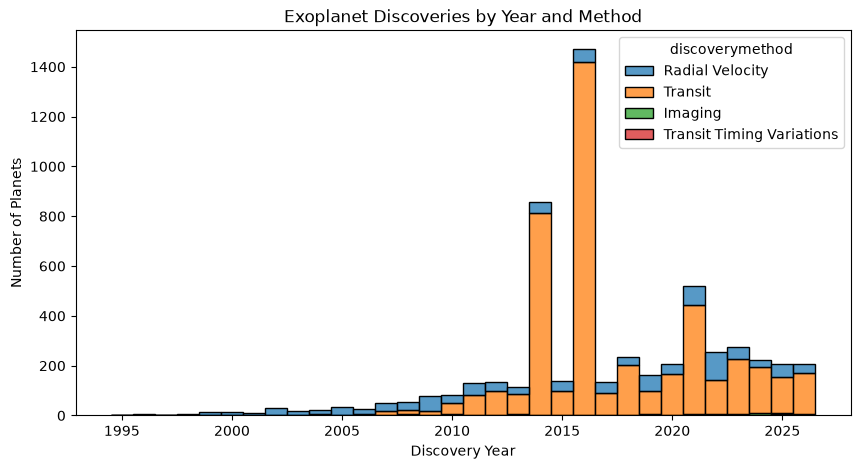

In [9]:
plt.figure(figsize=(10, 5))
top_methods = data['discoverymethod'].value_counts().nlargest(4).index
filtered = data[data['discoverymethod'].isin(top_methods)]

sns.histplot(data=filtered, x='disc_year', hue='discoverymethod', multiple='stack', discrete=True)
plt.title('Exoplanet Discoveries by Year and Method')
plt.xlabel('Discovery Year')
plt.ylabel('Number of Planets')
plt.show()

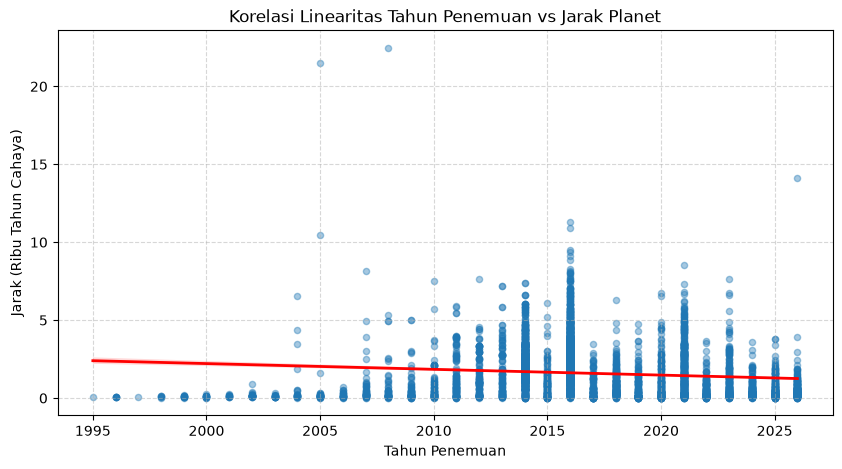

In [10]:
plt.figure(figsize=(10, 5))
sns.regplot(
    data=data, 
    x='disc_year', 
    y='sy_dist_kly', 
    scatter_kws={'alpha':0.4, 's':20}, 
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Korelasi Linearitas Tahun Penemuan vs Jarak Planet')
plt.xlabel('Tahun Penemuan')
plt.ylabel('Jarak (Ribu Tahun Cahaya)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Massa eksoplanet temuan dengan massa Bumi

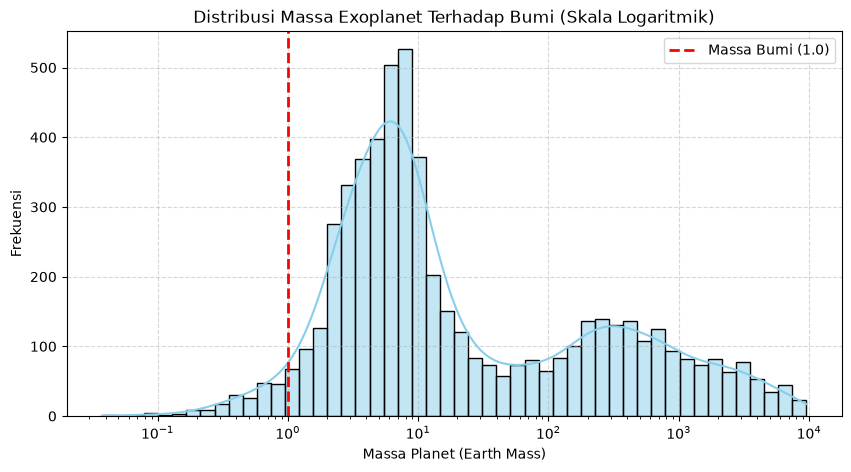

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(data['pl_bmasse'], bins=50, log_scale=True, kde=True, color='skyblue')
plt.axvline(1, color='red', linestyle='--', linewidth=2, label='Massa Bumi (1.0)')

plt.title('Distribusi Massa Exoplanet Terhadap Bumi (Skala Logaritmik)')
plt.xlabel('Massa Planet (Earth Mass)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [12]:
earth_like = data[
    (data['pl_rade'].between(0.8, 1.5)) &
    (data['pl_bmasse'].between(0.5, 5.0)) &
    (data['pl_eqt'].between(250, 300))
]

print(f"Ditemukan {len(earth_like)} planet dengan kemiripan tertinggi dengan Bumi.")
earth_like[['pl_name', 'disc_year', 'sy_dist_kly', 'pl_rade', 'pl_bmasse', 'pl_eqt']].sort_values(by='sy_dist_kly')

Ditemukan 9 planet dengan kemiripan tertinggi dengan Bumi.


,pl_name,disc_year,sy_dist_kly,pl_rade,pl_bmasse,pl_eqt
5875,Teegarden's Star b,2019,0.012488,1.050,1.160,277.00
1653,GJ 3323 b,2017,0.017522,1.230,2.020,290.06
1078,GJ 3378 b,2026,0.025176,1.320,2.300,272.00
5603,Wolf 1069 b,2023,0.031242,1.080,1.260,250.10
548,L 98-59 f,2025,0.034619,1.480,2.800,285.00
475,TOI-700 e,2023,0.101472,0.953,0.818,272.90
409,TOI-700 d,2020,0.101472,1.073,1.250,268.80
3551,K2-72 e,2016,0.216569,1.290,2.210,286.34
6150,Kepler-438 b,2015,0.638774,1.120,1.460,288.00


## Kesimpulan

- Mayoritas eksoplanet yang diketahui saat ini berasal dari lonjakan penemuan pada periode 2014–2016, yang didominasi kuat oleh metode pengamatan Transit.
- Meskipun teknologi observasi berkembang, mayoritas eksoplanet yang terdeteksi masih terpusat di radius galaksi yang relatif dekat dengan Bumi. Tidak ada perluasan jarak deteksi yang linear seiring bertambahnya tahun.
- Dari ribuan sampel eksoplanet yang ada, hanya 9 planet yang memiliki karakteristik fisik (massa dan radius) serta suhu ekuilibrium yang ideal dan sangat mirip dengan kondisi Bumi.